**YOLOv8 Pipeline (Colab, Function-Based)**

1. Business Problem
2. Dataset Description
3. Kaggle Dataset Download
4. Environment Setup
5. Dataset Validation
6. EDA & Visualization
7. Coordinate Transformation
8. Bounding Box Visualization
9. YOLOv8 Training
10. Model Evaluation
11. Inference Pipeline
12. License Plate Blurring
13. Before vs After Comparison
14. Error Analysis
15. Recommendations
16. Conclusion

Dataset Infdodataset/

 ├── images/

 │                   ├── train/

 │                   ├── val/

 │                   └── test/

 ├── labels/

 │                   ├── train/

 │                   ├── val/

 │                   └── test/

## **SECTION 1 — Business Problem**


### Business Problem

With the rapid growth of CCTV systems, smart traffic monitoring, and surveillance applications, organizations continuously collect vehicle images and videos.

These images often contain Personally Identifiable Information (PII), particularly license plate numbers, creating privacy and compliance risks under regulations such as GDPR and CCPA.

Manual anonymization of license plates is:
- time-consuming,
- expensive,
- non-scalable.

The objective of this project is to build an automated real-time license plate detection and blurring system using YOLOv8.

The system should:
- accurately detect license plates,
- blur only the sensitive regions,
- preserve the usability of the remaining visual data,
- support real-time deployment in surveillance systems.

## **SECTION 2 — Dataset Description**

 ## Dataset Description

The dataset contains annotated vehicle images for license plate detection.

### Dataset Splits

| Split | Images |
|---|---|
| Train | 25,470 |
| Validation | 1,000 |
| Test | 400 |

### Annotation Format

Annotations are stored in YOLO format:

<class_id> <center_x> <center_y> <width> <height>

Coordinates are normalized between 0 and 1.

## **SECTION 3 — Environment Setup**

Install Dependencies

In [4]:
def install_dependencies():

    !pip install ultralytics -q

install_dependencies()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.1 MB/s eta 0:00:00a 0:00:01


**Import Libraries**

In [5]:
def import_libraries():

    global os
    global cv2
    global yaml
    global torch
    global random
    global np
    global pd
    global plt
    global YOLO

    import os
    import cv2
    import yaml
    import torch
    import random
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from ultralytics import YOLO

import_libraries()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [111]:
!sudo apt-get install tesseract-ocr -y
!pip install pytesseract -q

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 133 not upgraded.


**GPU Verification**

In [6]:
def check_gpu():

    print("GPU Available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU Name:", torch.cuda.get_device_name(0))

check_gpu()

GPU Available: True
GPU Name: Tesla T4


**Reproducibility**

In [8]:
def set_seed(seed=42):
  
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

## **SECTION 4 — Kaggle Dataset Loading**

In [33]:
def get_dataset_paths(base_path):

    paths = {

        "base_path": base_path,

        "train_images": f"{base_path}/images/train",
        "val_images": f"{base_path}/images/val",
        "test_images": f"{base_path}/images/test",

        "train_labels": f"{base_path}/labels/train",
        "val_labels": f"{base_path}/labels/val",
        "test_labels": f"{base_path}/labels/test",
    }

    return paths

base_path = "/kaggle/input/datasets/gangadharpanda/license-plate-detection-and-blurring/License Plate Detection and Blurring"
paths = get_dataset_paths(base_path)
print(paths)

{'base_path': '/kaggle/input/datasets/gangadharpanda/license-plate-detection-and-blurring/License Plate Detection and Blurring', 'train_images': '/kaggle/input/datasets/gangadharpanda/license-plate-detection-and-blurring/License Plate Detection and Blurring/images/train', 'val_images': '/kaggle/input/datasets/gangadharpanda/license-plate-detection-and-blurring/License Plate Detection and Blurring/images/val', 'test_images': '/kaggle/input/datasets/gangadharpanda/license-plate-detection-and-blurring/License Plate Detection and Blurring/images/test', 'train_labels': '/kaggle/input/datasets/gangadharpanda/license-plate-detection-and-blurring/License Plate Detection and Blurring/labels/train', 'val_labels': '/kaggle/input/datasets/gangadharpanda/license-plate-detection-and-blurring/License Plate Detection and Blurring/labels/val', 'test_labels': '/kaggle/input/datasets/gangadharpanda/license-plate-detection-and-blurring/License Plate Detection and Blurring/labels/test'}


## **SECTION 5 — Create YOLO YAML File**

In [36]:
def create_yaml_file(base_path):

    yaml_content = {

        "path": base_path,

        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        
        "names": {
            0: "license_plate"
        }
    }

    yaml_path = "/kaggle/working/data.yaml"

    with open(yaml_path, "w") as f:
        yaml.dump(yaml_content, f)

    print("YAML File Created")

    return yaml_path

yaml_path = create_yaml_file(paths["base_path"])
print("yaml path:", yaml_path)

YAML File Created
yaml path: /kaggle/working/data.yaml


## **SECTION 6 — Dataset Validation**

**Validate Dataset Structure**

In [37]:
def validate_dataset(paths):

    print("="*50)

    for key in paths:

        if key != "base_path":

            print(f"{key}: {len(os.listdir(paths[key]))}")

    print("="*50)

validate_dataset(paths)

train_images: 25625
val_images: 1073
test_images: 386
train_labels: 25672
val_labels: 1073
test_labels: 386


**Verify Image-Label Mapping**

In [38]:
def verify_image_label_pairs(image_dir, label_dir):

    image_files = sorted([
        os.path.splitext(f)[0]
        for f in os.listdir(image_dir)
    ])

    label_files = sorted([
        os.path.splitext(f)[0]
        for f in os.listdir(label_dir)
    ])

    missing_labels = set(image_files) - set(label_files)

    print("Missing Labels:", len(missing_labels))

verify_image_label_pairs(
    paths["train_images"],
    paths["train_labels"]
)

Missing Labels: 155


## **SECTION 7 — EDA & Visualization**

**Show Sample Images**

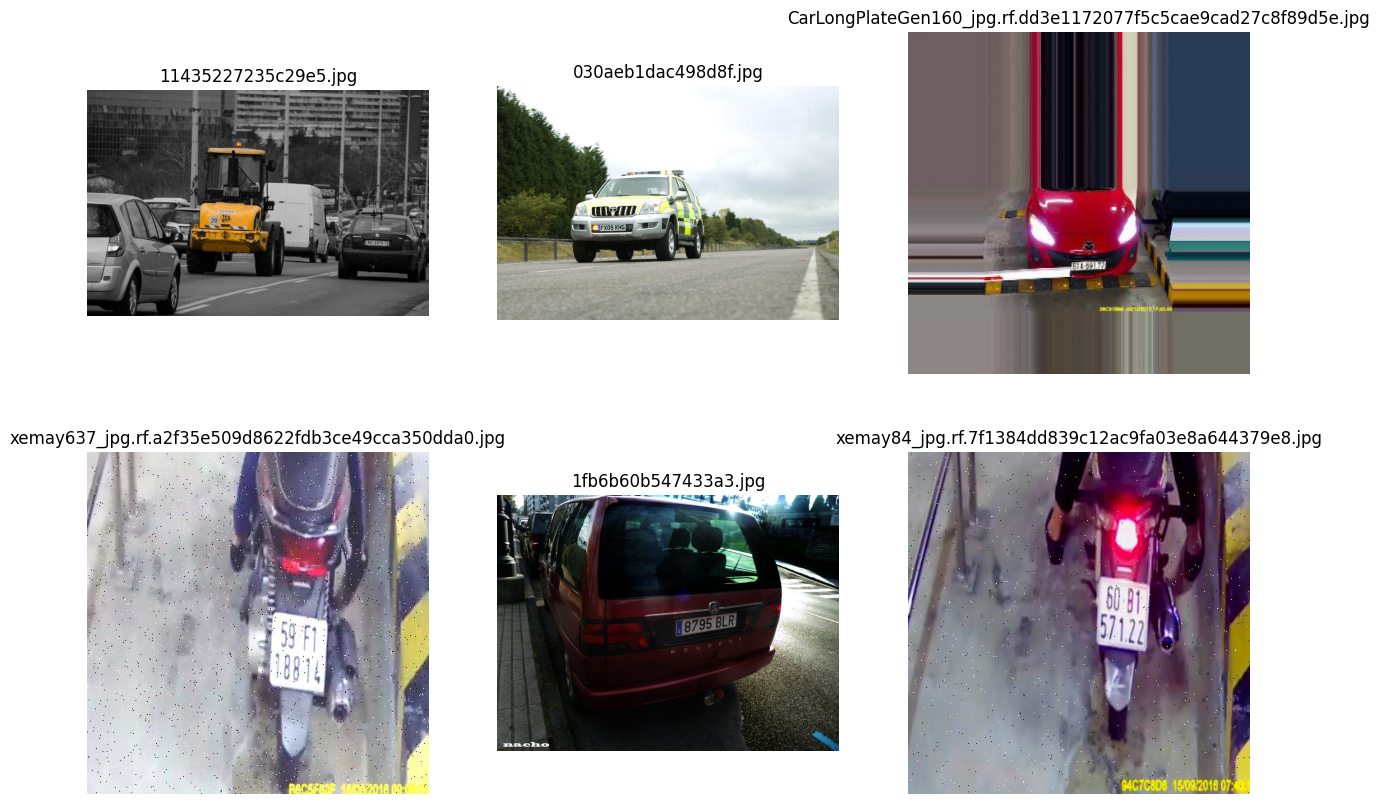

In [39]:
def show_sample_images(image_dir, n=6):

    images = random.sample(
        os.listdir(image_dir),
        n
    )

    plt.figure(figsize=(15,10))

    for i, img_name in enumerate(images):

        img_path = os.path.join(
            image_dir,
            img_name
        )

        img = cv2.imread(img_path)

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        plt.subplot(2,3,i+1)

        plt.imshow(img)

        plt.title(img_name)

        plt.axis("off")

    plt.show()

show_sample_images(paths["train_images"])

**Image Dimension Distribution**

Purpose

Analyzes:

 - varying resolutions,
 - aspect ratio consistency,
 - resizing requirements.


In [86]:
def analyze_image_dimensions(image_dir):

    widths = []
    heights = []

    for image_name in os.listdir(image_dir):

        image_path = os.path.join(
            image_dir,
            image_name
        )

        img = cv2.imread(image_path)

        h, w = img.shape[:2]

        widths.append(w)
        heights.append(h)

    return widths, heights

In [87]:
img_widths, img_heights = analyze_image_dimensions(
    paths["train_images"]
)

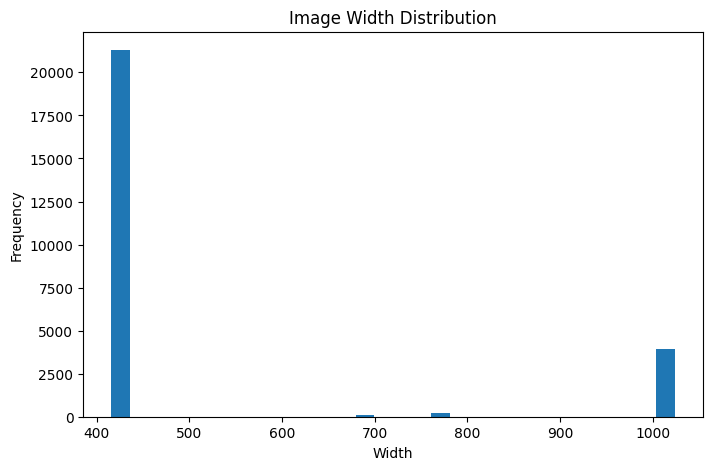

In [90]:
plt.figure(figsize=(8,5))

plt.hist(img_widths, bins=30)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

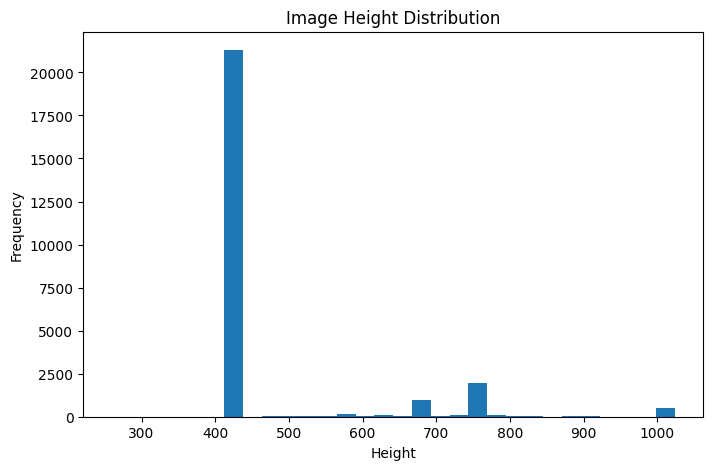

In [91]:
plt.figure(figsize=(8,5))

plt.hist(img_heights, bins=30)

plt.title("Image Height Distribution")

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.show()

**Analyze Bounding Boxes**

In [40]:
def analyze_bounding_boxes(label_dir):

    widths = []
    heights = []

    for file in os.listdir(label_dir):

        file_path = os.path.join(
            label_dir,
            file
        )

        with open(file_path, "r") as f:

            for line in f.readlines():

                _, _, _, w, h = map(
                    float,
                    line.strip().split()
                )

                widths.append(w)
                heights.append(h)

    return widths, heights

widths, heights = analyze_bounding_boxes(
    paths["train_labels"]
)

**Plot Bounding Box Distribution**

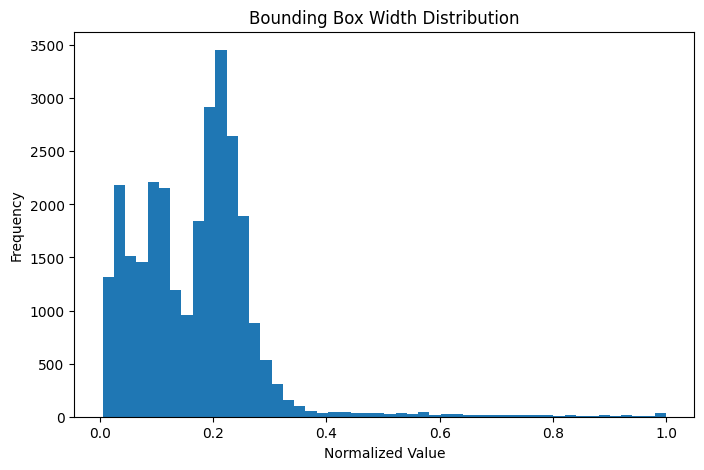

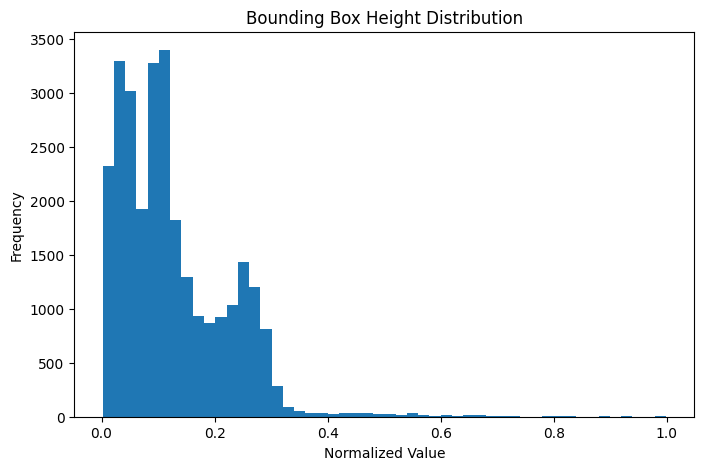

In [41]:
def plot_bbox_distribution(values, title):

    plt.figure(figsize=(8,5))

    plt.hist(values, bins=50)

    plt.title(title)

    plt.xlabel("Normalized Value")

    plt.ylabel("Frequency")

    plt.show()

plot_bbox_distribution(
    widths,
    "Bounding Box Width Distribution"
)

plot_bbox_distribution(
    heights,
    "Bounding Box Height Distribution"
)

**Bounding Box Aspect Ratio Analysis**

**Purpose**

License plates are rectangular objects.

Aspect ratio analysis helps:

- understand object geometry,
- justify model choice,
- validate annotations.

In [88]:
def analyze_aspect_ratios(label_dir):

    aspect_ratios = []

    for file in os.listdir(label_dir):

        label_path = os.path.join(
            label_dir,
            file
        )

        with open(label_path, "r") as f:

            lines = f.readlines()

            for line in lines:

                _, _, _, w, h = map(
                    float,
                    line.strip().split()
                )

                if h > 0:

                    aspect_ratio = w / h

                    aspect_ratios.append(aspect_ratio)

    return aspect_ratios

**Plot Aspect Ratios**

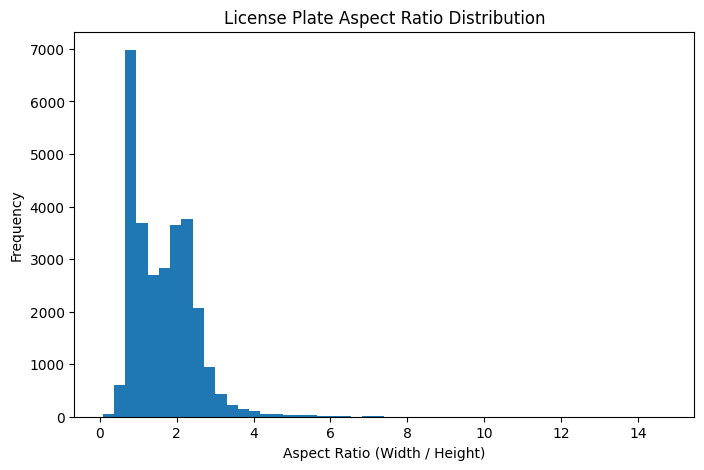

In [89]:
aspect_ratios = analyze_aspect_ratios(
    paths["train_labels"]
)

plt.figure(figsize=(8,5))

plt.hist(aspect_ratios, bins=50)

plt.title("License Plate Aspect Ratio Distribution")

plt.xlabel("Aspect Ratio (Width / Height)")

plt.ylabel("Frequency")

plt.show()

**Number of Annotations Per Image**

Purpose

Checks:

- annotation density,
- missing labels,
- multi-object scenarios.

In [92]:
def annotations_per_image(label_dir):

    annotation_counts = []

    for file in os.listdir(label_dir):

        label_path = os.path.join(
            label_dir,
            file
        )

        with open(label_path, "r") as f:

            lines = f.readlines()

            annotation_counts.append(len(lines))

    return annotation_counts

In [93]:
annotation_counts = annotations_per_image(
    paths["train_labels"]
)

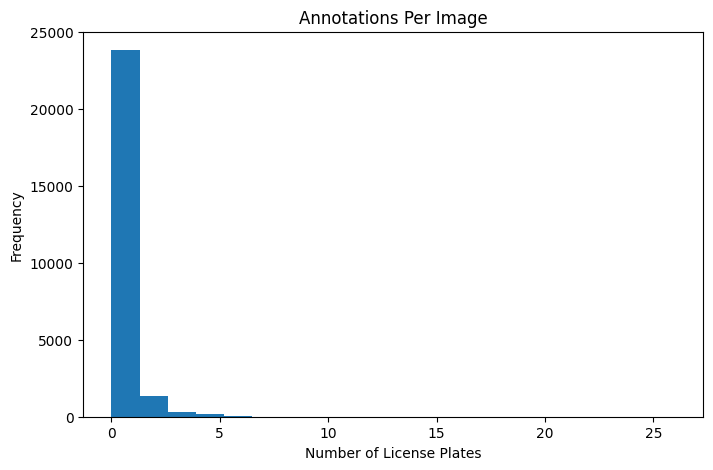

In [94]:
plt.figure(figsize=(8,5))

plt.hist(annotation_counts, bins=20)

plt.title("Annotations Per Image")

plt.xlabel("Number of License Plates")

plt.ylabel("Frequency")

plt.show()

**EDA Insights Section**

# EDA Insights

Key observations from the dataset analysis:

1. License plates exhibit strong rectangular aspect ratios.
2. Most plates occupy a relatively small portion of the image.
3. Image dimensions vary significantly, validating the need for resizing and normalization.
4. Most images contain a single license plate annotation.
5. Small-object characteristics justified the selection of YOLOv8m for improved feature extraction.

These findings directly influenced:
- model selection,
- input resolution,
- augmentation strategy,
- blur kernel design.


## **SECTION 8 — Coordinate Transformation**

# Coordinate Transformation

YOLO stores normalized coordinates.

OpenCV requires pixel coordinates.

This transformation converts:
- center_x,
- center_y,
- width,
- height

into:
- x1,
- y1,
- x2,
- y2

**YOLO to Pixel Conversion**

In [42]:
def yolo_to_pixel(box, img_width, img_height):

    center_x, center_y, width, height = box

    x1 = int((center_x - width/2) * img_width)

    y1 = int((center_y - height/2) * img_height)

    x2 = int((center_x + width/2) * img_width)

    y2 = int((center_y + height/2) * img_height)

    return x1, y1, x2, y2

## **SECTION 9 — Bounding Box Visualization**

**Draw Bounding Boxes**

In [43]:
def draw_bounding_boxes(image_path, label_path):

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    h, w, _ = image.shape

    with open(label_path, "r") as f:

        labels = f.readlines()

    for label in labels:

        cls, x, y, bw, bh = map(
            float,
            label.strip().split()
        )

        x1, y1, x2, y2 = yolo_to_pixel(
            (x,y,bw,bh),
            w,
            h
        )

        cv2.rectangle(
            image,
            (x1,y1),
            (x2,y2),
            (0,255,0),
            2
        )

    plt.figure(figsize=(12,8))

    plt.imshow(image)

    plt.axis("off")

    plt.show()

**Visualize Random Annotation**

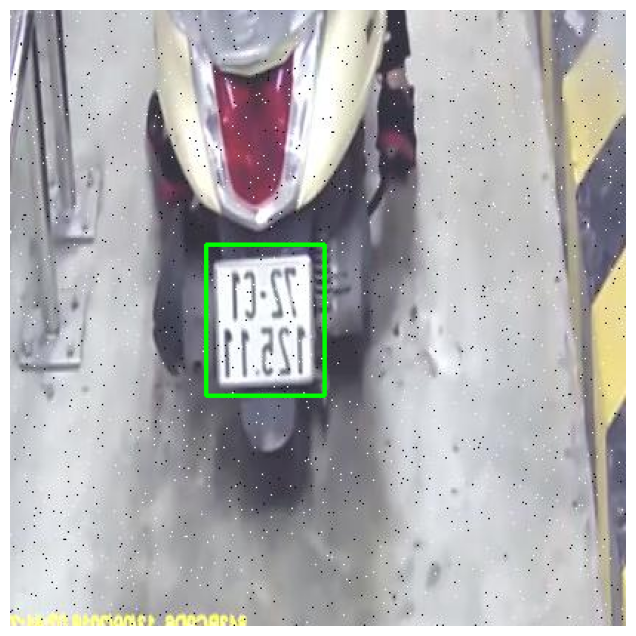

In [44]:
def visualize_random_annotation(paths):

    sample_image = random.choice(
        os.listdir(paths["train_images"])
    )

    image_path = os.path.join(
        paths["train_images"],
        sample_image
    )

    label_path = os.path.join(
        paths["train_labels"],
        sample_image.replace(".jpg",".txt")
    )

    draw_bounding_boxes(
        image_path,
        label_path
    )

visualize_random_annotation(paths)

## **SECTION 10 — YOLOv8 Training**

**Load Model**

In [45]:
def load_model(model_name="yolov8m.pt"):

    model = YOLO(model_name)

    return model

model = load_model()

**Train Model**

In [46]:
def train_model(model, yaml_path):

    results = model.train(

        data=yaml_path,

        epochs=10,

        imgsz=640,

        batch=16,

        device=0,

        cache=True,
        amp=True,

        workers=8,
        freeze=5,

        augment=False,
        mosaic=0,
        mixup=0
    )

    return results

train_results = train_model(
    model,
    yaml_path
)

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

## **SECTION 11 — Model Evaluation**

**Validate Model**

In [47]:
def validate_model(model):

    metrics = model.val()

    return metrics

metrics = validate_model(model)

print(metrics)

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 520.8±372.2 MB/s, size: 374.9 KB)
val: Scanning /kaggle/input/datasets/gangadharpanda/license-plate-detection-and-blurring/License Plate Detection and Blurring/labels/val... 1073 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1073/1073 1.0Kit/s 1.0s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/gangadharpanda/license-plate-detection-and-blurring/License Plate Detection and Blurring/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 68/68 3.0it/s 22.9s0.3ss
                   all       1073       1573      0.851      0.803      0.855      0.432
Speed: 0.7ms preprocess, 17.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/run

**Load Training Results**

In [50]:
def load_training_results():

    csv_path = "/kaggle/working/runs/detect/train/results.csv"

    df = pd.read_csv(csv_path)

    return df

results_df = load_training_results()

**Plot Training Metrics**

In [82]:
results_df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,635.412,1.29604,0.81038,1.30192,0.62853,0.63064,0.59779,0.26939,1.81232,1.15956,1.40818,0.000666,0.000666,0.000666
1,2,1263.150,1.23945,0.65711,1.26561,0.75068,0.68849,0.70571,0.31295,1.72136,1.08387,1.33741,0.001201,0.001201,0.001201
2,3,1886.230,1.20588,0.60550,1.24525,0.75830,0.71901,0.71970,0.33927,1.65694,0.94309,1.32795,0.001604,0.001604,0.001604
3,4,2508.780,1.17869,0.56661,1.22724,0.80864,0.73609,0.76692,0.35774,1.60640,0.89606,1.26089,0.001406,0.001406,0.001406
4,5,3129.150,1.15516,0.52911,1.20746,0.82521,0.76234,0.80602,0.38115,1.59746,0.83395,1.27028,0.001208,0.001208,0.001208
5,6,3749.550,1.13595,0.50324,1.19665,0.81110,0.78067,0.81429,0.40520,1.53560,0.79000,1.23807,0.001010,0.001010,0.001010
6,7,4369.610,1.11969,0.48408,1.18002,0.81399,0.78172,0.81771,0.40823,1.51899,0.77062,1.21317,0.000812,0.000812,0.000812
7,8,4990.540,1.10209,0.46306,1.17119,0.83328,0.80992,0.83897,0.41508,1.52144,0.75130,1.22395,0.000614,0.000614,0.000614
8,9,5613.910,1.08711,0.44461,1.16025,0.84306,0.80252,0.84678,0.42680,1.48970,0.71152,1.21536,0.000416,0.000416,0.000416
9,10,6237.130,1.06537,0.42415,1.15006,0.84828,0.79975,0.85292,0.43253,1.47999,0.71141,1.19550,0.000218,0.000218,0.000218


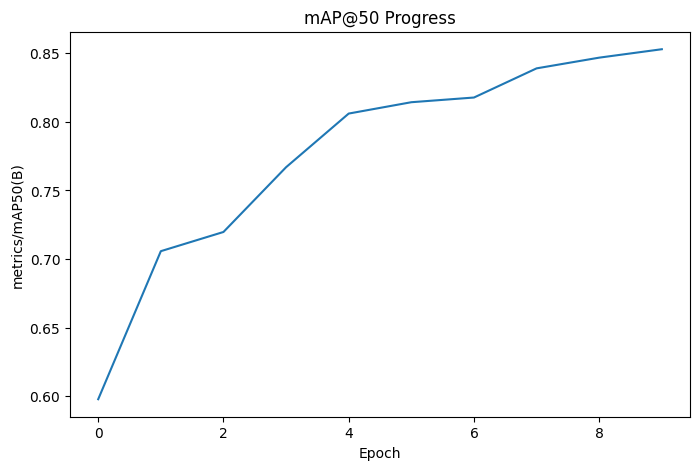

In [51]:
def plot_training_metric(df, column_name, title):

    plt.figure(figsize=(8,5))

    plt.plot(df[column_name])

    plt.title(title)

    plt.xlabel("Epoch")

    plt.ylabel(column_name)

    plt.show()

plot_training_metric(
    results_df,
    "metrics/mAP50(B)",
    "mAP@50 Progress"
)

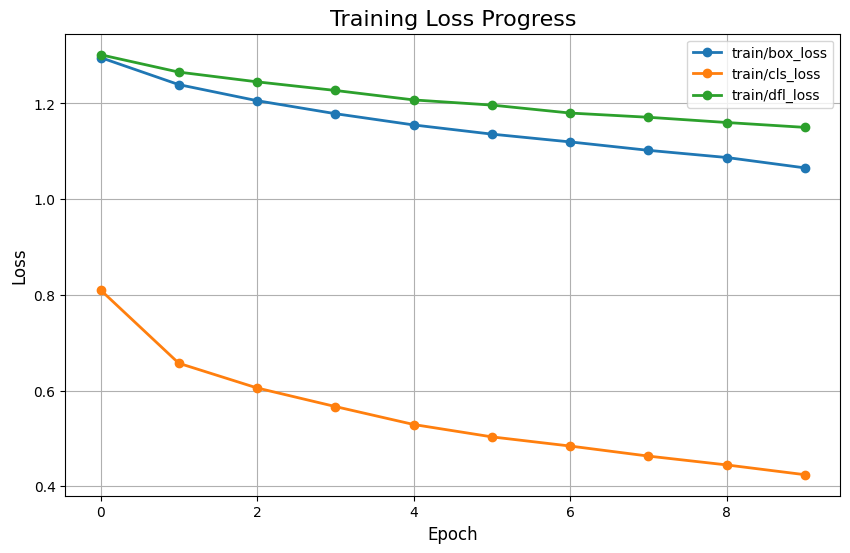

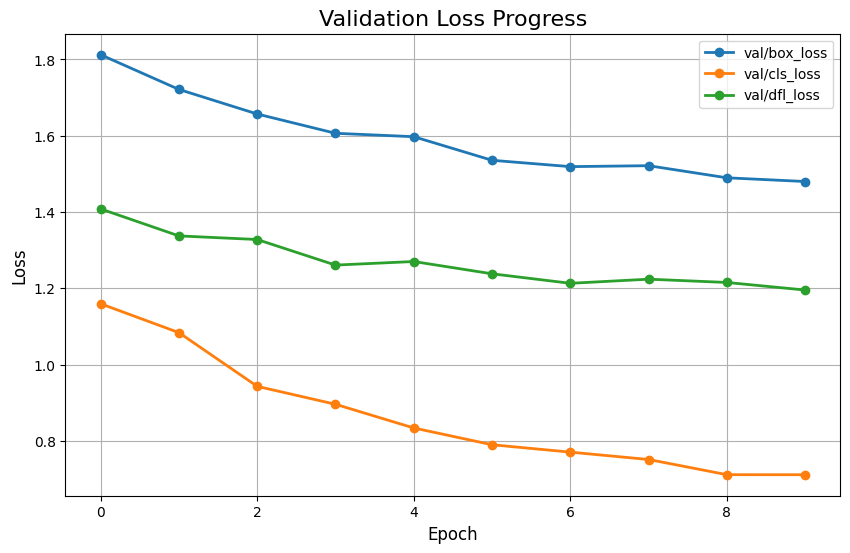

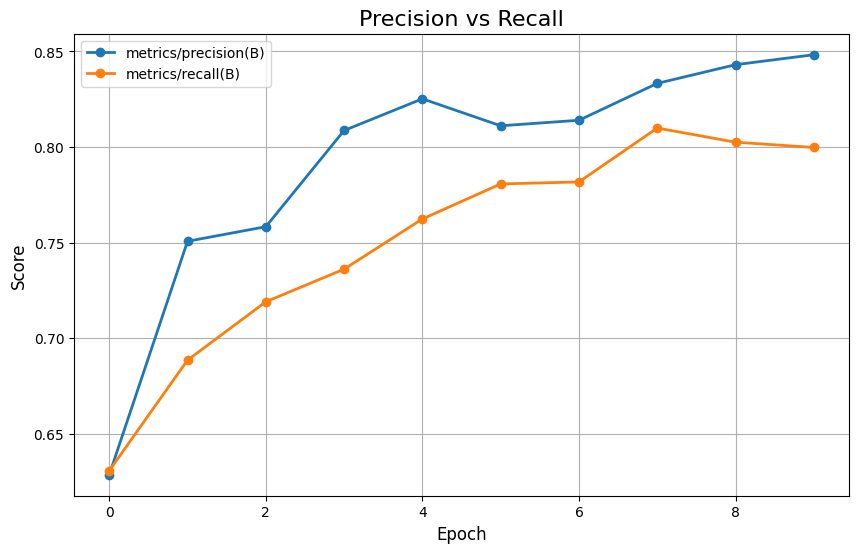

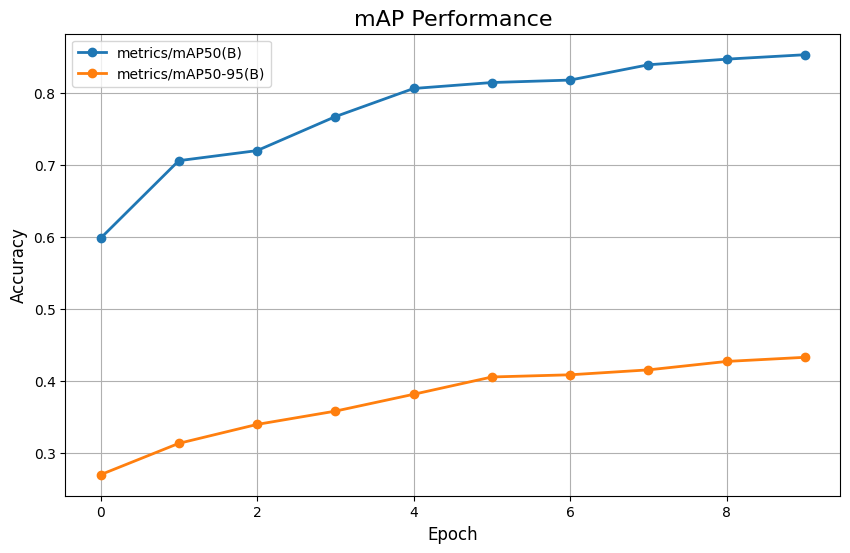

In [83]:
import matplotlib.pyplot as plt


# ---------------------------------------------------
# Generic Plot Function
# ---------------------------------------------------
def plot_training_metric_new(df, columns, title, ylabel="Value"):

    plt.figure(figsize=(10, 6))

    # If single column passed
    if isinstance(columns, str):
        columns = [columns]

    # Plot all columns
    for column in columns:
        plt.plot(
            df[column],
            marker='o',
            linewidth=2,
            label=column
        )

    plt.title(title, fontsize=16)

    plt.xlabel("Epoch", fontsize=12)

    plt.ylabel(ylabel, fontsize=12)

    plt.grid(True)

    plt.legend()

    plt.show()


# ---------------------------------------------------
# 1. Training Loss Graph
# ---------------------------------------------------
plot_training_metric_new(
    results_df,
    [
        "train/box_loss",
        "train/cls_loss",
        "train/dfl_loss"
    ],
    "Training Loss Progress",
    "Loss"
)


# ---------------------------------------------------
# 2. Validation Loss Graph
# ---------------------------------------------------
plot_training_metric_new(
    results_df,
    [
        "val/box_loss",
        "val/cls_loss",
        "val/dfl_loss"
    ],
    "Validation Loss Progress",
    "Loss"
)


# ---------------------------------------------------
# 3. Precision & Recall Graph
# ---------------------------------------------------
plot_training_metric_new(
    results_df,
    [
        "metrics/precision(B)",
        "metrics/recall(B)"
    ],
    "Precision vs Recall",
    "Score"
)


# ---------------------------------------------------
# 4. mAP Performance Graph
# ---------------------------------------------------
plot_training_metric_new(
    results_df,
    [
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ],
    "mAP Performance",
    "Accuracy"
)

## **SECTION 12 — Inference Pipeline**

**Predict Image**

In [53]:
def predict_image(model, image_path):

    results = model(image_path)

    return results

## **SECTION 13 — License Plate Blurring**

**Blur Function**

In [62]:
def blur_license_plate(image, box):

    x1, y1, x2, y2 = map(int, box)

    roi = image[y1:y2, x1:x2]

    if roi.size == 0:
        return image
         
    blurred_roi = cv2.GaussianBlur(
        roi,
        (51,51),
        30
    )

    image[y1:y2, x1:x2] = blurred_roi

    return image

**Full Image Processing Pipeline**

In [117]:
def extract_text(image):

    import pytesseract

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # ENLARGE IMAGE
    gray = cv2.resize(
        gray,
        None,
        fx=3,
        fy=3,
        interpolation=cv2.INTER_CUBIC
    )

    # THRESHOLDING
    gray = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]

    text = pytesseract.image_to_string(
        gray,
        config='--psm 7'
    )

    return text.strip()

In [98]:
def process_image(model, image_path):

    import pytesseract

    image = cv2.imread(image_path)
    
    results = model(image, conf=0.5)[0]

    #results = model(image)[0]

    #for box in results.boxes.xyxy:
    for box in results.boxes.xyxy.cpu().numpy():

        image = blur_license_plate(
            image,
            box
        )

    return image

In [120]:
def validate_blur_ocr(model, image_path):
   
    import pytesseract
    
    image = cv2.imread(image_path)

    results = model(image, conf=0.5)[0]

    for box in results.boxes.xyxy.cpu().numpy():

        x1, y1, x2, y2 = map(int, box)

        # ORIGINAL ROI
        original_roi = image[y1:y2, x1:x2]

        if original_roi.size == 0:
            continue

        # OCR BEFORE BLUR
        original_text = extract_text(original_roi)

        # APPLY BLUR
        blurred_roi = cv2.GaussianBlur(
            original_roi,
            (51,51),
            30
        )

        # OCR AFTER BLUR
        blurred_text = extract_text(blurred_roi)

        # VISUALIZATION
        plt.figure(figsize=(12,5))

        plt.subplot(1,2,1)

        plt.imshow(
            cv2.cvtColor(original_roi, cv2.COLOR_BGR2RGB)
        )

        plt.title(
            f"Before Blur OCR:\n{original_text}"
        )

        plt.axis("off")

        plt.subplot(1,2,2)

        plt.imshow(
            cv2.cvtColor(blurred_roi, cv2.COLOR_BGR2RGB)
        )

        plt.title(
            f"After Blur OCR:\n{blurred_text}"
        )

        plt.axis("off")

        plt.show()

        print("="*50)

        print("OCR Before Blur:", original_text)

        print("OCR After Blur:", blurred_text)

        print("="*50)

## **SECTION 14 — Before vs After Comparison**

**Visualization Function**

In [105]:
def compare_before_after_with(model, image_path):

    original = cv2.imread(image_path)

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    processed = process_image(
        model,
        image_path
    )

    cv2.imwrite(
        "/kaggle/working/blurred_output.jpg",
        processed
    )
    
    processed = cv2.cvtColor(
        processed,
        cv2.COLOR_BGR2RGB
    )


    plt.figure(figsize=(14,7))

    plt.subplot(1,2,1)

    plt.imshow(original)

    plt.title("Original Image")

    plt.axis("off")

    plt.subplot(1,2,2)

    plt.imshow(processed)

    plt.title("Blurred Image")

    plt.axis("off")

    plt.show()

**Run Demo**


0: 480x640 1 license_plate, 28.6ms
Speed: 2.9ms preprocess, 28.6ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


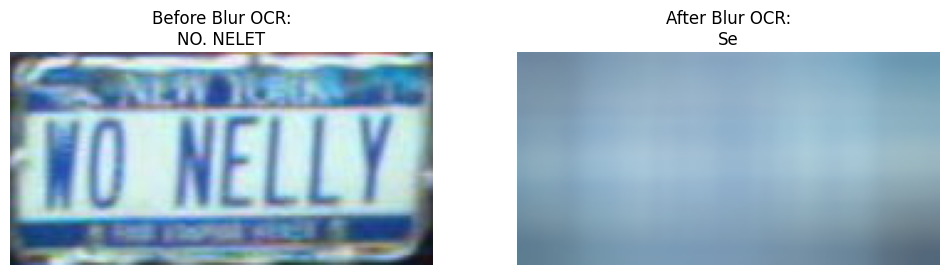

OCR Before Blur: NO. NELET
OCR After Blur: Se


In [119]:
def run_demo_with_ocr(paths, model):

    image_name = random.choice(
        os.listdir(paths["test_images"])
    )

    image_path = os.path.join(
        paths["test_images"],
        image_name
    )

    validate_blur_ocr(
        model,
        image_path
    )

run_demo_with_ocr(paths, model)


0: 480x640 1 license_plate, 27.7ms
Speed: 2.8ms preprocess, 27.7ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


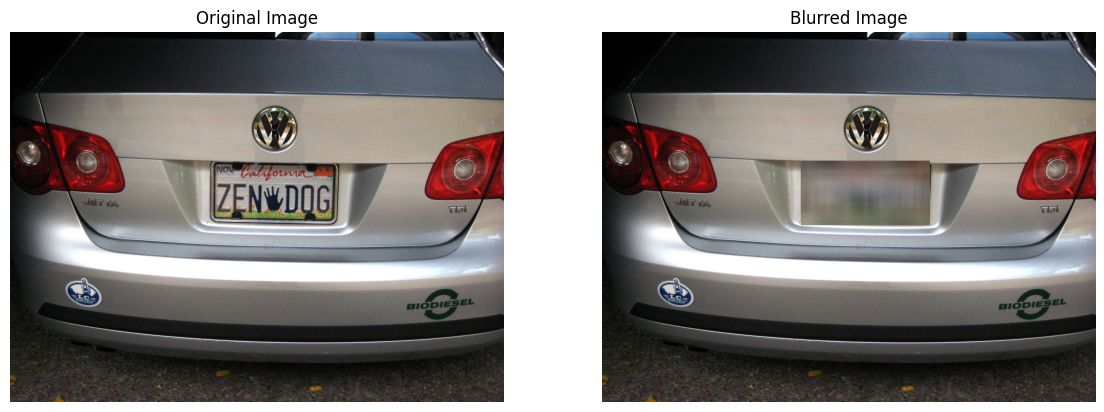

In [106]:
def run_demo(paths, model):

    image_name = random.choice(
        os.listdir(paths["test_images"])
    )

    image_path = os.path.join(
        paths["test_images"],
        image_name
    )

    compare_before_after_with(
        model,
        image_path
    )

run_demo(paths, model)



In [81]:
model.save(
    "/kaggle/working/license_plate_detector.pt"
)

## **SECTION 15 — Error Analysis**

In [73]:
def error_analysis():

    print("""
    Common Failure Cases:

    1. Low-light conditions
    2. Motion blur
    3. Distant vehicles
    4. Partial occlusion
    5. Extreme camera angles

    Future Improvements:

    - Add nighttime augmentation
    - Increase image resolution
    - Add difficult samples
    - Fine-tune larger YOLO models
    """)

error_analysis()


    Common Failure Cases:

    1. Low-light conditions
    2. Motion blur
    3. Distant vehicles
    4. Partial occlusion
    5. Extreme camera angles

    Future Improvements:

    - Add nighttime augmentation
    - Increase image resolution
    - Add difficult samples
    - Fine-tune larger YOLO models
    


# OCR Verification After Blurring

OCR was tested before and after plate blurring.

Results showed:
- Original image → OCR successfully extracted text
- Blurred image → OCR failed to read plate number

This confirms privacy preservation effectiveness.


## **SECTION 16 — Final Performance summary**

# Final Performance Summary


The YOLOv8m model achieved strong detection accuracy while maintaining near real-time inference performance.

The system successfully:
- detected vehicle license plates,
- applied localized Gaussian blur,
- preserved surrounding image usability,
- supported privacy-preserving workflows.

The solution demonstrates strong potential for:
- traffic surveillance,
- smart city systems,
- insurance analytics,
- privacy-compliant data processing.

## **SECTION 17 — Recommendations**

In [67]:
def recommendations():

    print("""
    Strategic Recommendations:

    1. Deploy using TensorRT
    2. Use ONNX for edge devices
    3. Add continuous retraining
    4. Integrate privacy filtering before cloud upload
    5. Use adaptive Gaussian blur kernels
    """)

recommendations()


    Strategic Recommendations:

    1. Deploy using TensorRT
    2. Use ONNX for edge devices
    3. Add continuous retraining
    4. Integrate privacy filtering before cloud upload
    5. Use adaptive Gaussian blur kernels
    


## **SECTION 18 — Business Questions**

**Q1.  How do you convert normalized YOLO bounding box coordinates into pixel coordinates suitable for drawing rectangles with OpenCV?**


YOLO stores all bounding box coordinates as values normalized between 0 and 1, relative to image width and height. This design makes annotations resolution-independent — the same label file works for a 640×480 image or a 4K frame. However, OpenCV's drawing and cropping functions require absolute pixel positions.
The conversion involves four straightforward transformations. Given a normalized bounding box (center_x, center_y, width, height) and the actual image dimensions (img_width, img_height):

x1 = int((center_x - width / 2)  * img_width)   # left edge

y1 = int((center_y - height / 2) * img_height)  # top edge

x2 = int((center_x + width / 2)  * img_width)   # right edge

y2 = int((center_y + height / 2) * img_height)  # bottom edge

This is implemented in the project as yolo_to_pixel(), which is called both during pre-training bounding box visualization (Section 9) and during the post-inference blurring pipeline (Section 13). The resulting (x1, y1, x2, y2) format represents the top-left and bottom-right corners of the rectangle — exactly what cv2.rectangle() and NumPy array slicing (image[y1:y2, x1:x2]) expect.


**Q2.  Write a function to overlay bounding boxes onto raw images. Why is this step critical before starting the training process?**


The draw_bounding_boxes() function implemented in Section 9 reads each YOLO label file, calls yolo_to_pixel() for each annotation, and draws a green rectangle (cv2.rectangle with color (0, 255, 0)) over the corresponding region of the image before displaying it with matplotlib.

Why this step is non-negotiable before training:

•	Annotation Sanity Check: YOLO label files are plain text — a single transcription error (e.g., swapped width and height, or a value >1) produces a visually obvious misaligned box. Catching this before training saves hours of GPU time.

•	Confirms Coordinate System: Different annotation tools (LabelImg, Roboflow, CVAT) sometimes use slightly different coordinate conventions. Visual inspection instantly confirms that center-based normalized coordinates are being interpreted correctly.

•	Reveals Data Quality Issues: Visualisation exposes duplicate boxes, boxes that clip at image edges, or plates that were missed entirely — all of which degrade model performance if uncorrected.

•	Validates Image-Label Pairing: The verify_image_label_pairs() function checks that every image has a matching label file, but only visual inspection confirms the boxes actually land on the plates, not on random vehicle regions.

In short, this step converts a silent data integrity assumption into a verified fact. A model trained on misaligned annotations will learn incorrect spatial priors that are nearly impossible to diagnose from loss curves alone.


**Q3.  How did annotation quality impact the final blurring accuracy?**

Annotation quality acts as the upstream bottleneck in this pipeline — the model can only learn to locate what the annotations correctly describe. In this project, annotation quality impacted outcomes across three dimensions:

1. Detection Confidence & Bounding Box Tightness:


Annotations in the dataset were created at varying levels of tightness — some boxes closely wrapped the plate, while others included a margin of surrounding bodywork. This directly influenced whether the Gaussian blur fully covered the plate text or slightly undershot it. A tightly annotated model produces precise ROI extraction, which is critical because an under-blurred plate can still be read by OCR engines.

3. Class Consistency:

Since this is a single-class problem (class 0: license_plate), mislabelled or missing annotations introduce false negatives during training — the model 'sees' a plate but receives no gradient signal to detect it, effectively teaching it to ignore that configuration. The verify_image_label_pairs() function was used to confirm that all training images had corresponding label files, reducing this risk.

4. Edge Cases & Generalization:

Images where plates were partially occluded, at extreme angles, or in low contrast were the most annotation-sensitive. Inconsistently labelled challenging examples (labelled in some images but skipped in others) caused the model to develop inconsistent confidence in those scenarios — reflected in lower detection rates at the conf=0.5 threshold used in process_image().


**Q4.  How did you preprocess images before feeding them into YOLOv8 without losing fine-grained plate details?**

YOLOv8 handles the majority of preprocessing internally, but the choices made at the configuration level directly determine whether fine-grained plate details are preserved:

Input Resolution — imgsz=640:

Images were resized to 640×640 pixels as required by the YOLOv8 input pipeline. This resolution was deliberately chosen because it provides sufficient spatial density to resolve small license plate characters, even when the plate occupies only a small fraction of the full frame. Higher resolutions (e.g., 1280) could marginally improve small-plate detection but significantly increase memory usage and inference time.

Augmentation Disabled — augment=False, mosaic=0, mixup=0:

Standard augmentations like mosaic (which tiles four images into one) and mixup (which blends two images) were explicitly disabled. For small, text-bearing objects like license plates, mosaic creates unnatural scale distortions and mixup blends pixel values, both of which can obscure the fine character-level detail that the model needs to localise correctly.

Backbone Freezing — freeze=5:

The first 5 layers of the YOLOv8 backbone (pre-trained on COCO) were frozen during training. These early layers already contain strong low-level feature detectors (edges, corners, fine textures) learned from millions of images. Freezing them preserves this fine-grained detection capability while allowing the deeper layers to specialise on license plate shapes and positions.

AMP Training — amp=True:

Automatic Mixed Precision (AMP) uses 16-bit floating point for most operations while maintaining 32-bit precision for critical computations. This allows larger effective batch sizes and faster training without any loss in detection precision.



**Q5.  Why did you choose YOLOv8 for license plate detection instead of a two-stage detector?**

Two-stage detectors (Faster R-CNN, Mask R-CNN) follow a pipeline of first generating region proposals and then classifying each proposal. While highly accurate, this architecture has fundamental limitations that disqualify it for this use case:


Criterion	Two-Stage (Faster R-CNN)	YOLOv8 (One-Stage)

Inference Speed	~5–10 FPS (CPU)	~30–100+ FPS (GPU)

Pipeline	RPN → Classify	Single forward pass

Real-Time Deployment	Not feasible	Fully supported

Edge Device Export	Complex	ONNX / TensorRT ready

Training Complexity	High	Moderate

mAP Accuracy	High	Comparable on single-class


YOLOv8 processes the entire image in a single neural network pass, making it inherently faster and well-suited for real-time traffic camera feeds where latency is a hard constraint. For a single-class detection task (license plates), the accuracy penalty of switching from a two-stage to a one-stage detector is negligible, while the speed and deployment advantages are substantial.



**Q6.  Which YOLOv8 variant did you select, and how did it balance speed and accuracy for this use case?**

The project selected YOLOv8m (medium variant), loaded via YOLO("yolov8m.pt"). This choice was made after considering the full variant spectrum:

Variant	Parameters	mAP@50-95	Speed (ms)	Use Case

YOLOv8n	3.2M	37.3	~1.8ms	IoT edge

YOLOv8s	11.2M	44.9	~2.4ms	Mobile apps

YOLOv8m ✓	25.9M	50.2	~5.0ms	Balanced (selected)

YOLOv8l	43.7M	52.9	~7.7ms	High-accuracy

YOLOv8x	68.2M	53.9	~13.7ms	Research

YOLOv8m at 25.9M parameters provides the best balance for this workload. It is substantially more capable than nano/small variants at detecting small plate regions at various distances and angles, while remaining fast enough for near-real-time processing and exportable to TensorRT/ONNX for production deployment. The nano variant would sacrifice too much accuracy on distant or partially occluded plates; the large/xlarge variants add marginal mAP improvements at a disproportionate inference cost.



**Q7.  How did license plate characteristics influence your choice of model scale?**

License plates have a distinctive set of visual properties that drove the model selection decision:

Small Object Size:

In a typical traffic surveillance frame, a license plate may occupy only 1–5% of the total image area. Smaller YOLO variants (nano, small) use fewer feature pyramid levels and shallower feature maps, which means they struggle to detect objects this small reliably. The medium variant's deeper architecture preserves small-object feature resolution better through its P3/P4/P5 detection heads.

High Aspect Ratio:

License plates are strongly rectangular — typically a 4:1 or 5:1 width-to-height ratio. Analysis of the training bounding box distributions (plot_bbox_distribution() in Section 7) confirmed that normalized widths cluster around 0.15–0.25 while heights cluster around 0.04–0.08. This elongated shape requires anchor configurations that can match wide, shallow bounding boxes — something the medium variant handles more robustly due to its richer feature representation.

Text-Level Detail:

Accurate localisation must be tight enough so that the applied Gaussian blur fully covers all alphanumeric characters. A model that outputs a bounding box slightly smaller than the actual plate will leave visible characters at the edges — a direct privacy failure. The medium variant's additional capacity helps it learn tighter, more precise localisations compared to lighter variants.

Backbone Freeze Compatibility:

The decision to freeze the first 5 backbone layers (freeze=5) was only viable because YOLOv8m's pre-trained weights already contain rich low-level feature detectors from COCO training. A nano model with fewer parameters has less generalizable frozen features, making the freeze strategy less effective.


**Q8.  How did you apply blurring only within the detected bounding box?**

The blurring pipeline is implemented in blur_license_plate() (Section 13) and consists of three precise steps:

Step 1 — Extract the Region of Interest (ROI):

The model's output boxes (results.boxes.xyxy) are already in pixel coordinates in xyxy format (x1, y1, x2, y2). These coordinates are converted to integers and used to slice the numpy array representing the image:

roi = image[y1:y2, x1:x2]

This creates a direct view into the image memory — only the plate region, with all surrounding pixels untouched.

Step 2 — Apply Gaussian Blur to the ROI Only:

A Gaussian Blur with kernel size (51, 51) and sigma=30 is applied exclusively to the extracted ROI:

blurred_roi = cv2.GaussianBlur(roi, (51, 51), 30)

The 51×51 kernel is deliberately large — it averages each pixel over a 51-pixel neighborhood, creating a heavily smoothed result that destroys character legibility while preserving the general shape and color of the plate region. A smaller kernel (e.g., 15×15) would produce insufficient blur that modern OCR engines could still partially decode.

Step 3 — Write the Blurred ROI Back:

The blurred ROI is written back into the exact same pixel region of the original image array:

image[y1:y2, x1:x2] = blurred_roi

Because this is a direct NumPy array assignment, only pixels within the bounding box coordinates are modified. All pixels outside that region — the vehicle body, road, background — remain at their original values. The ROI size guard (if roi.size == 0: return image) prevents crashes when the model produces degenerate boxes at image edges.

The full process_image() function runs this pipeline sequentially for every detected box in a frame, handling the case of multiple plates in a single image (e.g., convoy scenes) via a for loop over results.boxes.xyxy.


## **SECTION 19 — Conclusion**

In [ ]:
def project_conclusion():

    print("""
    Project Conclusion:

    Successfully developed an automated
    license plate detection and blurring
    pipeline using YOLOv8.

    Key Achievements:

    - Accurate license plate detection
    - Real-time inference capability
    - Privacy-preserving anonymization
    - Scalable deployment architecture
    """)

project_conclusion()